# DQN

In [ ]:

import torch
import pyspiel
from open_spiel.python import rl_environment
from open_spiel.python.pytorch import dqn

import matplotlib.pyplot as plt
from tqdm import tqdm

# Environment
env = rl_environment.Environment("pentago")
num_actions = env.action_spec()["num_actions"]
state_size = env.observation_spec()["info_state"][0]


### Adversarial Training

Episode 0/150000 | P0 loss: None | P1 loss: None | 
P0 winrate vs random: 97.5%


/Users/colegiusto/College/ECE270/FinalProject/.venv/lib/python3.12/site-packages/open_spiel/python/pytorch/dqn.py:338: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  predictions = self._q_values[list(action_indices)]


P0 winrate vs P1: 93.5%
ep: 0.99998713
Episode 500/150000 | P0 loss: 0.046435799449682236 | P1 loss: 0.052345968782901764 | 
Episode 1000/150000 | P0 loss: 0.05658793821930885 | P1 loss: 0.049329597502946854 | 
Episode 1500/150000 | P0 loss: 0.029218114912509918 | P1 loss: 0.030576368793845177 | 
Episode 2000/150000 | P0 loss: 0.058435823768377304 | P1 loss: 0.03403402492403984 | 
P0 winrate vs random: 88.5%
P0 winrate vs P1: 82.0%
ep: 0.9412078599999999
Episode 2500/150000 | P0 loss: 0.06568989902734756 | P1 loss: 0.06857781857252121 | 
Episode 3000/150000 | P0 loss: 0.03822324052453041 | P1 loss: 0.045282889157533646 | 
Episode 3500/150000 | P0 loss: 0.03761310875415802 | P1 loss: 0.06229664757847786 | 
Episode 4000/150000 | P0 loss: 0.022781996056437492 | P1 loss: 0.060521017760038376 | 
P0 winrate vs random: 79.0%
P0 winrate vs P1: 70.5%
ep: 0.91095742
Episode 4500/150000 | P0 loss: 0.060392532497644424 | P1 loss: 0.03275566175580025 | 
Episode 5000/150000 | P0 loss: 0.083528511226

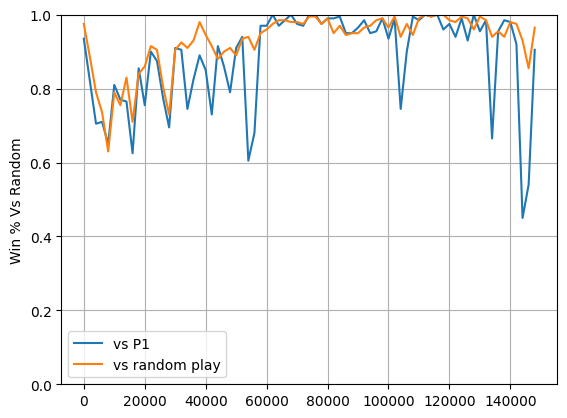

In [289]:
from open_spiel.python.algorithms import random_agent

rand_agent = random_agent.RandomAgent(
        player_id=1,
        num_actions=num_actions
    )

agents = [
    dqn.DQN(
        player_id=i,
        state_representation_size=state_size,
        num_actions=num_actions,
        hidden_layers_sizes=(256, 256),
        replay_buffer_capacity=50_000,
        batch_size=128,
        learning_rate=1e-4,
        update_target_network_every=4000,
        learn_every=50,
        discount_factor=0.99,
        epsilon_start=1.0,
        epsilon_end=0.01+0.15*i,
        epsilon_decay_duration=1_000_000,
        optimizer_str="adam",
        loss_str="huber"
    )
    for i in range(2)
]

for agent in agents:
    agent._q_network.load_state_dict(torch.load("agent0_vs_rand.pt"))

# Training loop
num_episodes = 150_000
winrates = []
rand_winrates = []
eps = []
for ep in range(num_episodes):
    time_step = env.reset()

    while not time_step.last():
        current_player = time_step.observations["current_player"]
        agent_output = agents[current_player].step(time_step)
        time_step = env.step([agent_output.action])

    # Let both agents observe the terminal state
    train = len(winrates)==0 or winrates[-1] < 0.90
    agents[0].step(time_step, is_evaluation=not train)
    agents[1].step(time_step)
    if not train:
        agents[0]._prev_timestep = None  # prevent stale transition into next episode
        agents[0]._prev_action = None
        time_step = env.reset()

        while not time_step.last():
            current_player = time_step.observations["current_player"]
            agent = agents[0] if current_player == 0 else rand_agent
            agent_output = agent.step(time_step)
            time_step = env.step([agent_output.action]) 

        agents[0].step(time_step)

    

    # Logging
    if ep % 500 == 0:
        print(f"Episode {ep}/{num_episodes} | "
              f"P0 loss: {agents[0].loss} | "
              f"P1 loss: {agents[1].loss} | ")
        if ep % 2000 == 0:
            test_ep = 200
            wins,_,_ = eval_vs_random(agents[0], verbose=False, num_episodes=test_ep)
            rate = wins/test_ep
            print(f"P0 winrate vs random: {rate*100}%")
            rand_winrates.append(rate)

            wins,_,_ = evaluate_agents(*agents, verbose=False, num_episodes=test_ep)
            rate = wins/test_ep
            print(f"P0 winrate vs P1: {rate*100}%")
            winrates.append(rate)
            print(f"ep: {agents[0]._get_epsilon(False)}")
            eps.append(ep)
            

plt.plot(eps, winrates)
plt.plot(eps, rand_winrates)
plt.legend(["vs P1", "vs random play"])
plt.ylim([0,1])
plt.grid()
plt.ylabel("Win % Vs Random")



# Save the trained agents
torch.save(agents[0]._q_network.state_dict(), "agent0.pt")
torch.save(agents[1]._q_network.state_dict(), "agent1.pt")
print("Training complete!")

### Random Training

Episode 0/80000 | P0 loss: None | 
P0 winrate: 42.0%


/Users/colegiusto/College/ECE270/FinalProject/.venv/lib/python3.12/site-packages/open_spiel/python/pytorch/dqn.py:338: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  predictions = self._q_values[list(action_indices)]


Episode 500/80000 | P0 loss: 0.21492552757263184 | 
Episode 1000/80000 | P0 loss: 0.284603089094162 | 
Episode 1500/80000 | P0 loss: 0.16127952933311462 | 
Episode 2000/80000 | P0 loss: 0.10232990980148315 | 
P0 winrate: 46.0%
Episode 2500/80000 | P0 loss: 0.04760022088885307 | 
Episode 3000/80000 | P0 loss: 0.044438865035772324 | 
Episode 3500/80000 | P0 loss: 0.04961857199668884 | 
Episode 4000/80000 | P0 loss: 0.04056397080421448 | 
P0 winrate: 56.00000000000001%
Episode 4500/80000 | P0 loss: 0.06437259167432785 | 
Episode 5000/80000 | P0 loss: 0.044268663972616196 | 
Episode 5500/80000 | P0 loss: 0.020094314590096474 | 
Episode 6000/80000 | P0 loss: 0.03899473696947098 | 
P0 winrate: 48.0%
Episode 6500/80000 | P0 loss: 0.045157916843891144 | 
Episode 7000/80000 | P0 loss: 0.026477904990315437 | 
Episode 7500/80000 | P0 loss: 0.03797776252031326 | 
Episode 8000/80000 | P0 loss: 0.029816659167408943 | 
P0 winrate: 44.0%
Episode 8500/80000 | P0 loss: 0.0335603691637516 | 
Episode 9000

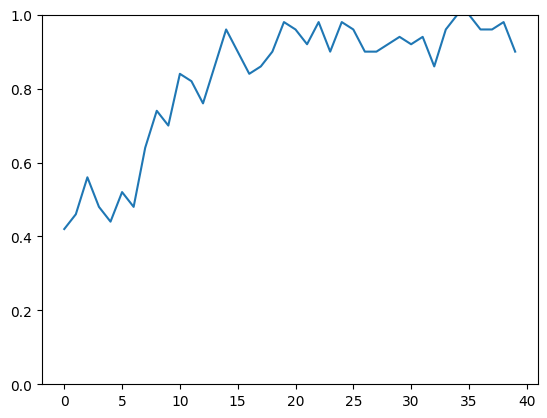

In [285]:
from open_spiel.python.algorithms import random_agent


agents = [
    dqn.DQN(
        player_id=0,
        state_representation_size=state_size,
        num_actions=num_actions,
        hidden_layers_sizes=(256,256),
        replay_buffer_capacity=100_000,
        batch_size=128,
        learning_rate=1e-4,
        update_target_network_every=500,
        learn_every=50,
        discount_factor=0.99,
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay_duration=50_000,
        optimizer_str="adam",
        loss_str="huber",
    ),
    random_agent.RandomAgent(
        player_id=1,
        num_actions=num_actions
    )
]

# Training loop
num_episodes = 80_000

winrates = []

for ep in range(num_episodes):
    time_step = env.reset()

    while not time_step.last():
        current_player = time_step.observations["current_player"]
        agent_output = agents[current_player].step(time_step)
        time_step = env.step([agent_output.action])

    # Let both agents observe the terminal state
    for agent in agents:
        agent.step(time_step)

    # Logging
    if ep % 500 == 0:
        print(f"Episode {ep}/{num_episodes} | "
              f"P0 loss: {agents[0].loss} | ")
        if ep % 2000 == 0:
            test_ep = 50
            wins,_,_ = eval_vs_random(agents[0], verbose=False, num_episodes=test_ep)
            rate = wins/test_ep
            print(f"P0 winrate: {rate*100}%")
            winrates.append(rate)
plt.plot(winrates)
plt.ylim([0,1])



# Save the trained agents
torch.save(agents[0]._q_network.state_dict(), "agent0_vs_rand.pt")

print("Training complete!")

## AlphaZero

RecursionError: maximum recursion depth exceeded while calling a Python object

## Evaluate

In [260]:
def evaluate_agents(p0, p1, num_episodes=1000, verbose=False):
    wins, losses, draws = 0, 0, 0

    for ep in range(num_episodes):
        time_step = env.reset()
        while not time_step.last():
            current_player = time_step.observations["current_player"]
            if current_player == 0:
                action = p0.step(time_step, is_evaluation=True).action
            else:
                action = p1.step(time_step).action
            time_step = env.step([action])

        final_returns = env._state.returns()
        if final_returns[0] > 0:
            wins += 1
        elif final_returns[0] < 0:
            losses += 1
        else:
            draws += 1
        if verbose and (ep + 1) % 100 == 0:
            print(f"Episode {ep+1}: W={wins} L={losses} D={draws} | "
                  f"Winrate: {wins/(ep+1):.2%}")
        
    if verbose:
        print(f"\nFinal over {num_episodes} games:")
        print(f"  Wins:   {wins}  ({wins/num_episodes:.2%})")
        print(f"  Losses: {losses}  ({losses/num_episodes:.2%})")
        print(f"  Draws:  {draws}  ({draws/num_episodes:.2%})")

    return (wins, losses, draws)


### Vs Random

In [295]:
from open_spiel.python.algorithms import random_agent

def eval_vs_random(trained_agent, num_episodes=1000, agent_player_id=0, verbose=True):
    rand_agent = random_agent.RandomAgent(
        player_id=1 - agent_player_id,
        num_actions=num_actions
    )
    
    p0 = trained_agent if agent_player_id == 0 else rand_agent
    p1 = trained_agent if agent_player_id == 1 else rand_agent
    return evaluate_agents(p0, p1, num_episodes=num_episodes, verbose=verbose)

# Evaluate after training
print(eval_vs_random(agents[0], num_episodes=10000, agent_player_id=0))

Episode 100: W=99 L=0 D=1 | Winrate: 99.00%
Episode 200: W=199 L=0 D=1 | Winrate: 99.50%
Episode 300: W=298 L=1 D=1 | Winrate: 99.33%
Episode 400: W=396 L=2 D=2 | Winrate: 99.00%
Episode 500: W=496 L=2 D=2 | Winrate: 99.20%
Episode 600: W=596 L=2 D=2 | Winrate: 99.33%
Episode 700: W=695 L=3 D=2 | Winrate: 99.29%
Episode 800: W=795 L=3 D=2 | Winrate: 99.38%
Episode 900: W=894 L=3 D=3 | Winrate: 99.33%
Episode 1000: W=994 L=3 D=3 | Winrate: 99.40%
Episode 1100: W=1094 L=3 D=3 | Winrate: 99.45%
Episode 1200: W=1193 L=4 D=3 | Winrate: 99.42%
Episode 1300: W=1293 L=4 D=3 | Winrate: 99.46%
Episode 1400: W=1393 L=4 D=3 | Winrate: 99.50%
Episode 1500: W=1492 L=4 D=4 | Winrate: 99.47%
Episode 1600: W=1591 L=5 D=4 | Winrate: 99.44%
Episode 1700: W=1691 L=5 D=4 | Winrate: 99.47%
Episode 1800: W=1791 L=5 D=4 | Winrate: 99.50%
Episode 1900: W=1891 L=5 D=4 | Winrate: 99.53%
Episode 2000: W=1990 L=6 D=4 | Winrate: 99.50%
Episode 2100: W=2090 L=6 D=4 | Winrate: 99.52%
Episode 2200: W=2190 L=6 D=4 | Wi

### Vs Optimal

In [ ]:
import requests
import subprocess
import json
import numpy as np
import random
import os

# Path to the built solve binary — adjust if your pentago repo is elsewhere
PENTAGO_DIR = os.path.join(os.path.dirname(os.path.abspath("main.ipynb")), "pentago")
SOLVE_BIN = os.path.join(PENTAGO_DIR, "bazel-bin/pentago/mid/solve")

def encode_state(state):
    """Encode an OpenSpiel Pentago state into Sloan's 64-bit ID."""
    obs = np.array(state.observation_tensor(0)).reshape(3, 6, 6)
    quad_defs = [
        (range(0, 3), range(0, 3)),  # UL
        (range(0, 3), range(3, 6)),  # UR
        (range(3, 6), range(0, 3)),  # LL
        (range(3, 6), range(3, 6)),  # LR
    ]
    final_id = 0
    for i, (r_range, c_range) in enumerate(quad_defs):
        quad_sum, power = 0, 0
        for r in r_range:
            for c in c_range:
                if obs[0][r][c] == 1: cell_val = 1
                elif obs[1][r][c] == 1: cell_val = 2
                else: cell_val = 0
                quad_sum += cell_val * (3 ** power)
                power += 1
        final_id |= (quad_sum << (16 * i))
    return final_id

def get_perfect_moves(id):
    URL = f"https://us-central1-naml-148801.cloudfunctions.net/pentago/{id}"
    res = requests.get(URL)
    if not res.ok:
        raise Exception("API Request Failed: ", res.reason)
    return res.json()

# Cache midengine results to avoid re-solving the same position
_midengine_cache = {}

def midengine_solve(board_id):
    """Call the C++ midengine for positions with >=18 stones. Results are cached."""
    if board_id in _midengine_cache:
        return _midengine_cache[board_id]
    result = subprocess.run(
        [SOLVE_BIN],
        input=str(board_id),
        capture_output=True,
        text=True,
        timeout=60
    )
    if result.returncode != 0:
        raise Exception(f"midengine failed: {result.stderr.strip()}")
    if not result.stdout.strip():
        raise Exception(f"midengine returned no output (stderr: {result.stderr.strip()!r})")
    data = json.loads(result.stdout)
    _midengine_cache[board_id] = data
    return data

def choose_best_action(env: rl_environment.Environment, play_as=1):
    state = env.get_state
    state_id = encode_state(state)
    num_stones = state.move_number()

    try:
        if num_stones < 18:
            # Use Sloan cloud API (DB-backed, handles <=17 stones)
            ids = get_perfect_moves(state_id)
            ids = {k: v for k, v in ids.items()
                   if not k.endswith('m') and k != str(state_id)}
        else:
            # Use local C++ midengine for >=18 stones
            results = midengine_solve(state_id)
            # Keep only post-rotation states (bit 63 = 0, middle=false)
            # excluding the current board itself
            ids = {
                k: v for k, v in results.items()
                if (int(k) >> 63) == 0 and k != str(state_id)
            }
    except Exception as e:
        print(f"Oracle unavailable ({e}), falling back to random")
        return random.choice(state.legal_actions())

    if not ids:
        return random.choice(state.legal_actions())

    # Both players always minimize.
    # Values are from the mover's perspective AT THE SUCCESSOR, so
    # min = the next mover (our opponent) loses = we win.
    # This is true for both player 0 and player 1.
    best_value = min(ids.values())
    winning_ids = {k for k, v in ids.items() if v == best_value}

    for action in random.sample(state.legal_actions(), k=len(state.legal_actions())):
        next_state = state.clone()
        next_state.apply_action(action)
        if str(encode_state(next_state)) in winning_ids:
            return action

    print("WARNING: No matching action found, falling back to random")
    return random.choice(state.legal_actions())


def eval_vs_optimal(trained_agent: dqn.DQN, num_episodes=1000, agent_player_id=0):
    wins, losses, draws = 0, 0, 0

    for ep in tqdm(range(num_episodes)):
        time_step = env.reset()

        while not time_step.last():
            current_player = time_step.observations["current_player"]
            if current_player == agent_player_id:
                action = trained_agent.step(time_step, is_evaluation=True).action
            else:
                action = choose_best_action(env, 1 - agent_player_id)
            time_step = env.step([action])

        final_returns = env._state.returns()
        if final_returns[agent_player_id] > 0:
            wins += 1
        elif final_returns[agent_player_id] < 0:
            losses += 1
        else:
            draws += 1

        if (ep + 1) % 10 == 0:
            print(f"Episode {ep+1}: W={wins} L={losses} D={draws} | "
                  f"Winrate: {wins/(ep+1):.2%} | "
                  f"Cache size: {len(_midengine_cache)}")

    print(f"\nFinal over {num_episodes} games:")
    print(f"  Wins:   {wins}  ({wins/num_episodes:.2%})")
    print(f"  Losses: {losses}  ({losses/num_episodes:.2%})")
    print(f"  Draws:  {draws}  ({draws/num_episodes:.2%})")


In [310]:
eval_vs_optimal(agents[1], num_episodes=10, agent_player_id=1)

Oracle unavailable (Expecting value: line 1 column 1 (char 0)), falling back to random


KeyboardInterrupt: 